# Replication Study: U-Net Brain Tumor Segmentation

**Research advisor:** Dr. Ackley Will  
**Affiliation:** Andrews University Computer Science Department

This notebook documents a 2D U-Net replication study using the BraTS 2024 glioma dataset. The experiment combines four aligned MRI modalities to predict a binary whole-tumor mask, evaluates variation across configurable random seeds, and selects a probability threshold using validation data. Flip and rotation augmentation are implemented but currently disabled.

## MRI modalities

Each MRI volume emphasizes different tissue characteristics:

- **T1 (t1n):** anatomical structure, including gray matter, white matter, and ventricles
- **Contrast-enhanced T1 (t1c):** areas where contrast crosses the blood-brain barrier
- **T2 (t2w):** water content and tissue differences
- **FLAIR (t2f):** edema and tumor-related fluid, with normal cerebrospinal fluid suppressed

The modalities are spatially aligned, so the same slice can be stacked into a four-channel model input.

In [1]:
# Libraries used for data handling, visualization, and model training
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import nibabel as nib  # reads the NIfTI volumes supplied by BraTS

import tensorflow_addons as tfa
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dropout,
    Conv2DTranspose,
    concatenate,
)


In [2]:
# Use deterministic TensorFlow operations on both CPU and GPU

gpus = tf.config.list_physical_devices("GPU")
print("GPU is available" if gpus else "GPU is NOT available")
tf.config.experimental.enable_op_determinism()


GPU is available


In [3]:
# Shared settings for every seeded run
EPOCHS = 100
BUFFER_SIZE = 500
BATCH_SIZE = 32

# Use two runs while validating the notebook; expand this for the full study
SEEDS = list(range(2))

# Spatial resolution used by the U-Net
img_height = 144
img_width  = 192

In [4]:
# Find each patient directory in the local BraTS training set
data_path = os.path.join(
    os.getcwd(),
    'BraTS2024-BraTS-GLI-TrainingData',
    'training_data1_v2',
)

patient_dirs = sorted([
    os.path.join(data_path, d)
    for d in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, d))
])

print(f"Total patients found: {len(patient_dirs)}")
print("Example patient folder:", patient_dirs[0])


Total patients found: 1350
Example patient folder: C:\Users\lev\Documents\Dev\Brain Tumor Segmentation\BraTS2024-BraTS-GLI-TrainingData\training_data1_v2\BraTS-GLI-00005-100


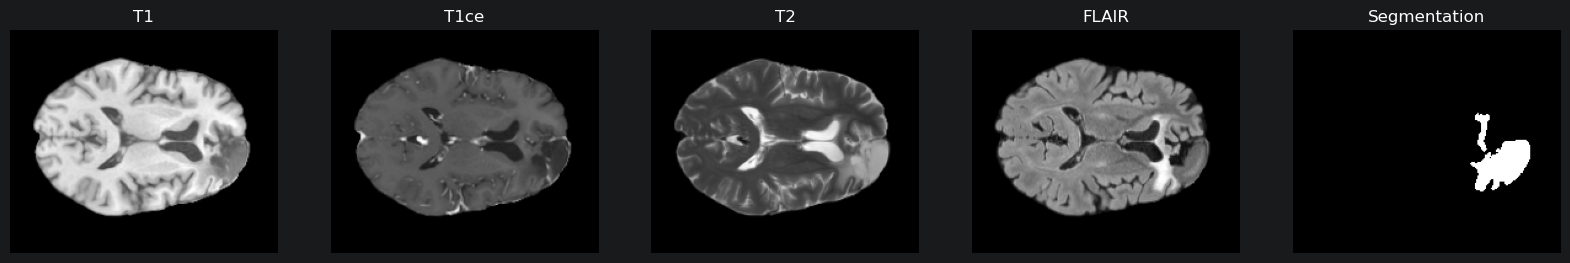

In [5]:
# Inspect one patient before building the data pipeline
N = 2
patient_dir = patient_dirs[N]

# Match each modality and its segmentation file
t1_path    = [f for f in os.listdir(patient_dir) if 't1n' in f][0]
t1ce_path  = [f for f in os.listdir(patient_dir) if 't1c' in f][0]
t2_path    = [f for f in os.listdir(patient_dir) if 't2w' in f][0]
flair_path = [f for f in os.listdir(patient_dir) if 't2f' in f][0]
seg_path   = [f for f in os.listdir(patient_dir) if 'seg' in f][0]

# Load the full 3D volumes
t1    = nib.load(os.path.join(patient_dir, t1_path)).get_fdata()
t1ce  = nib.load(os.path.join(patient_dir, t1ce_path)).get_fdata()
t2    = nib.load(os.path.join(patient_dir, t2_path)).get_fdata()
flair = nib.load(os.path.join(patient_dir, flair_path)).get_fdata()
mask  = nib.load(os.path.join(patient_dir, seg_path)).get_fdata()

# Stack the aligned modalities along a new channel axis: (H, W, D, 4)
image_4ch = np.stack([t1, t1ce, t2, flair], axis=-1)

# This study uses one central axial slice from each volume
slice_idx = image_4ch.shape[2] // 2  # floor division produces a valid integer index

fig, arr = plt.subplots(1, 5, figsize=(20, 5))

titles = ["T1", "T1ce", "T2", "FLAIR", "Segmentation"]

for i in range(4):
    arr[i].imshow(image_4ch[:, :, slice_idx, i], cmap="gray")
    arr[i].set_title(titles[i])
    arr[i].axis("off")

arr[4].imshow(mask[:, :, slice_idx] > 0, cmap="gray")
arr[4].set_title(titles[4])
arr[4].axis("off")

plt.show()

## Data preparation

The following cells pair each patient's four MRI volumes with the supplied segmentation mask. Volumes missing any required file are left out. Each pair is then reduced to its central axial slice and prepared for the TensorFlow pipeline.

In [6]:
# Pair the four modality files with the segmentation mask for each patient
image_list = []
mask_list  = []

def first_match(files, substring: str):
    matches = [f for f in files if substring in f.lower()]
    return matches[0] if matches else None

for p in patient_dirs:
    files = os.listdir(p)
    t1_f    = first_match(files, "t1n")
    t1ce_f  = first_match(files, "t1c")
    t2_f    = first_match(files, "t2w")
    flair_f = first_match(files, "t2f")
    seg_f   = first_match(files, "seg")

    # A complete four-channel input and mask are required for this study
    if any(x is None for x in [t1_f, t1ce_f, t2_f, flair_f, seg_f]):
        continue

    image_list.append((
        os.path.join(p, t1_f),
        os.path.join(p, t1ce_f),
        os.path.join(p, t2_f),
        os.path.join(p, flair_f),
    ))
    mask_list.append(os.path.join(p, seg_f))

# Check a few pairs before loading the image data
for image_paths, mask_path in list(zip(image_list, mask_list))[:3]:
    print(image_paths, mask_path)

('C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t1n.nii.gz', 'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t1c.nii.gz', 'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t2w.nii.gz', 'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t2f.nii.gz') C:\Users\lev\Documents\Dev\Brain Tumor Segmentation\BraTS2024-BraTS-GLI-TrainingData\training_data1_v2\BraTS-GLI-00005-100\BraTS-GLI-00005-100-seg.nii.gz
('C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-101\\BraTS-GLI-00005-101-t1n.nii.gz', 'C:\\Users\\le

In [7]:
# Build a dataset of file paths; volume loading happens in the map step below
image_filenames = tf.constant(image_list)   # shape: (N, 4)
masks_filenames = tf.constant(mask_list)    # shape: (N,)

dataset = tf.data.Dataset.from_tensor_slices((image_filenames, masks_filenames))

for image_paths, mask_path in dataset.take(1):
    print(image_paths)  # 4 modality paths
    print(mask_path)

tf.Tensor(
[b'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t1n.nii.gz'
 b'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t1c.nii.gz'
 b'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t2w.nii.gz'
 b'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-t2f.nii.gz'], shape=(4,), dtype=string)
tf.Tensor(b'C:\\Users\\lev\\Documents\\Dev\\Brain Tumor Segmentation\\BraTS2024-BraTS-GLI-TrainingData\\training_data1_v2\\BraTS-GLI-00005-100\\BraTS-GLI-00005-100-seg.nii.gz', shape=(), dtype=string)


In [8]:

# Load one four-modality input and its binary whole-tumor mask
def process_path_4ch(image_paths, mask_path):
    def _load_4ch_and_mask(imgs, msk):
        # tf.numpy_function may pass either a tuple or a NumPy array
        if not isinstance(imgs, (tuple, list)):
            imgs = list(imgs)

        def to_str(x):
            if isinstance(x, (bytes, bytearray)):
                return x.decode()
            if hasattr(x, "decode"):
                return x.decode()
            return str(x)

        t1_p, t1ce_p, t2_p, flair_p = [to_str(x) for x in imgs]
        seg_p = to_str(msk)

        # Load each NIfTI volume as float32 to limit memory use
        t1    = nib.load(t1_p).get_fdata(dtype=np.float32)
        t1ce  = nib.load(t1ce_p).get_fdata(dtype=np.float32)
        t2    = nib.load(t2_p).get_fdata(dtype=np.float32)
        flair = nib.load(flair_p).get_fdata(dtype=np.float32)
        seg   = nib.load(seg_p).get_fdata(dtype=np.float32)

        # Use the same central axial slice from every aligned volume
        shape = flair.shape
        z = shape[2] // 2

        x = np.stack([t1[..., z], t1ce[..., z], t2[..., z], flair[..., z]], axis=-1).astype(np.float32)  # (H,W,4)
        y = (seg[..., z] > 0).astype(np.float32)[..., None]  # (H,W,1)

        return x, y

    x, y = tf.numpy_function(_load_4ch_and_mask, [image_paths, mask_path], [tf.float32, tf.float32])
    x.set_shape([None, None, 4])
    y.set_shape([None, None, 1])
    return x, y

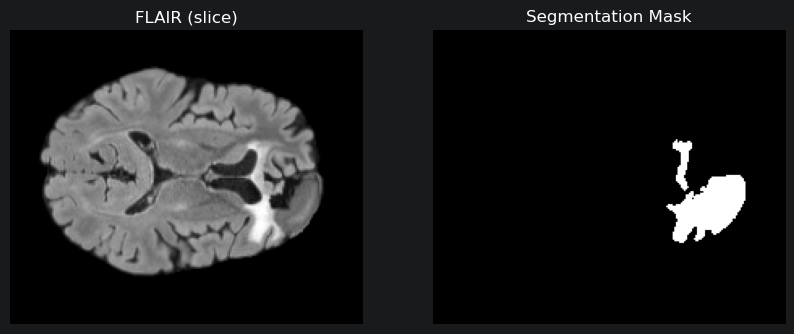

In [9]:
# Confirm that an input slice and its first non-empty mask remain aligned
image_ds = dataset.map(process_path_4ch, num_parallel_calls=tf.data.AUTOTUNE)

for image, mask in image_ds:
    if tf.reduce_sum(mask) > 0:
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(image[..., 3], cmap="gray")  # FLAIR
        ax[0].set_title("FLAIR (slice)")
        ax[0].axis("off")

        ax[1].imshow(mask[..., 0], cmap="gray")
        ax[1].set_title("Segmentation Mask")
        ax[1].axis("off")

        plt.show()
        break

In [10]:
# Flipping was tested but left disabled because it reduced validation performance
def random_flip(x, y, prob=0):
    y = tf.ensure_shape(y, [None, None, 1])

    flip_lr = tf.random.uniform([]) < prob
    flip_ud = tf.random.uniform([]) < prob

    def do_lr():
        return tf.image.flip_left_right(x), tf.image.flip_left_right(y)

    def do_ud(x_in, y_in):
        return tf.image.flip_up_down(x_in), tf.image.flip_up_down(y_in)

    x, y = tf.cond(flip_lr, do_lr, lambda: (x, y))
    x, y = tf.cond(flip_ud, lambda: do_ud(x, y), lambda: (x, y))

    return x, y

In [11]:
# Rotation is available for future experiments but intentionally disabled by default
def random_rotate(x, y, max_deg=5.0, prob=0):
    rotate_flag = tf.random.uniform([], 0, 1) < prob

    def do_rotate():
        angle_rad = tf.random.uniform(
            [],
            minval=-max_deg * np.pi / 180.0,
            maxval= max_deg * np.pi / 180.0,
        )

        fill_x = tf.reduce_min(x)  # keep padded corners dark after normalization

        x_rot = tfa.image.rotate(
            x, angles=angle_rad, interpolation="bilinear",
            fill_mode="constant", fill_value=fill_x
        )
        y_rot = tfa.image.rotate(
            y, angles=angle_rad, interpolation="nearest",
            fill_mode="constant", fill_value=0.0
        )
        return x_rot, y_rot

    return tf.cond(rotate_flag, do_rotate, lambda: (x, y))

In [12]:
# Resize each slice and normalize the four MRI channels independently
def preprocess(image, mask):
    # Bilinear interpolation suits MRI intensities; nearest neighbor preserves mask labels
    image = tf.image.resize(image, (img_height, img_width), method="bilinear")
    mask  = tf.image.resize(mask, (img_height, img_width), method="nearest")

    # Normalize each modality without mixing their intensity distributions
    mean = tf.reduce_mean(image, axis=(0, 1), keepdims=True)
    std  = tf.math.reduce_std(image, axis=(0, 1), keepdims=True)
    image = (image - mean) / (std + 1e-6)

    # Collapse all tumor labels into one whole-tumor class
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask


processed_image_ds = image_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

for image, mask in processed_image_ds.take(1):
    sample_image, sample_mask = image, mask
    print(sample_image.shape)
    print(sample_mask.shape)

(144, 192, 4)
(144, 192, 1)


In [13]:
# Keep Python, NumPy, and TensorFlow random generators on the same seed
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

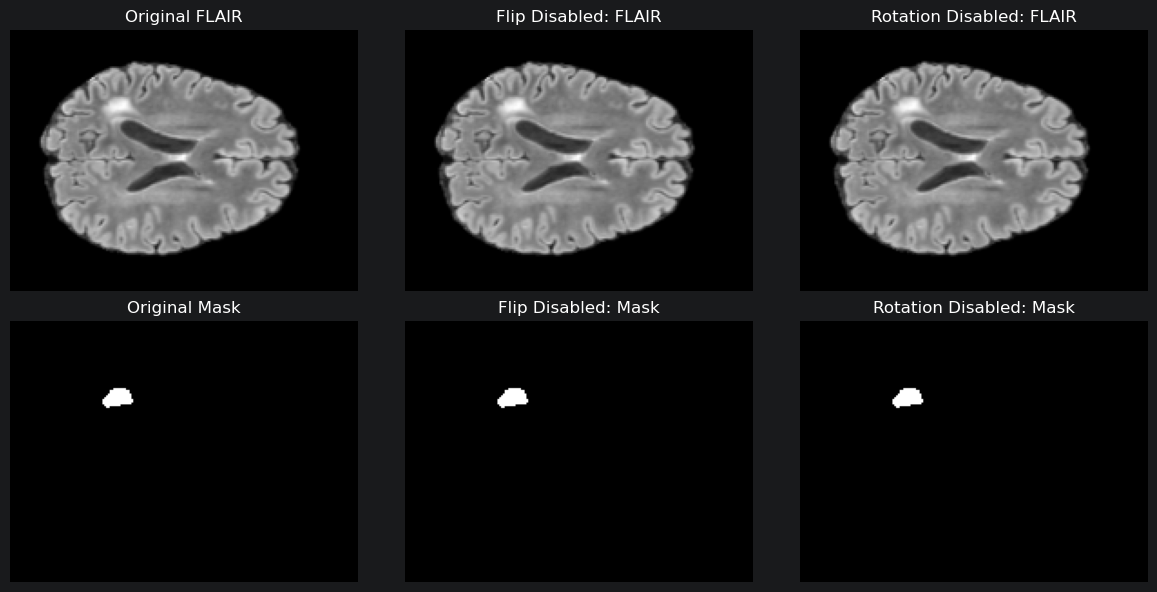

In [14]:
# Confirm that the disabled augmentations leave an example unchanged

set_seed(0)

idx = 4

for i, (image, mask) in enumerate(processed_image_ds):
    if i == idx:
        x, y = image, mask
        break

# Both default probabilities are zero, so these copies match the original.
x_flip, y_flip = random_flip(x, y)
x_rot,  y_rot  = random_rotate(x, y)

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1); plt.imshow(x[..., 3], cmap="gray");      plt.title("Original FLAIR");      plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(y[..., 0], cmap="gray");      plt.title("Original Mask");       plt.axis("off")

plt.subplot(2, 3, 2); plt.imshow(x_flip[..., 3], cmap="gray"); plt.title("Flip Disabled: FLAIR");   plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(y_flip[..., 0], cmap="gray"); plt.title("Flip Disabled: Mask");    plt.axis("off")

plt.subplot(2, 3, 3); plt.imshow(x_rot[..., 3], cmap="gray");  plt.title("Rotation Disabled: FLAIR"); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(y_rot[..., 0], cmap="gray");  plt.title("Rotation Disabled: Mask");  plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Build a reproducible approximately 70/15/15 split with no omitted examples
TOTAL = len(image_list)
train_count = round(0.70 * TOTAL)
val_count   = round(0.15 * TOTAL)
test_count  = TOTAL - train_count - val_count

def build_datasets(seed: int):
    base = tf.data.Dataset.from_tensor_slices((image_filenames, masks_filenames))
    base = base.shuffle(TOTAL, seed=seed, reshuffle_each_iteration=False)

    train_raw = base.take(train_count)
    rest = base.skip(train_count)

    val_raw  = rest.take(val_count)
    test_raw = rest.skip(val_count).take(test_count)

    train_dataset = (
        train_raw
        .map(process_path_4ch, num_parallel_calls=tf.data.AUTOTUNE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        # Both augmentation functions currently have probability zero.
        .map(random_flip, num_parallel_calls=tf.data.AUTOTUNE)
        .map(random_rotate, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(BUFFER_SIZE, seed=seed, reshuffle_each_iteration=True)
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )


    val_dataset = (
        val_raw
        .map(process_path_4ch, num_parallel_calls=tf.data.AUTOTUNE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )
    
    test_dataset = (
        test_raw
        .map(process_path_4ch, num_parallel_calls=tf.data.AUTOTUNE)
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )

    return train_dataset, val_dataset, test_dataset


In [16]:
# Report the number of examples assigned to each split

print(f"Total examples: {TOTAL}")
print(f"Train examples: {train_count}")
print(f"Validation examples: {val_count}")
print(f"Test examples: {test_count}")

Total examples: 1350
Train examples: 945
Validation examples: 202
Test examples: 203


# U-Net model

The network follows the standard U-Net shape: the encoder learns increasingly abstract features while reducing spatial resolution, and the decoder restores resolution with help from skip connections. The final sigmoid layer returns a tumor probability for each pixel.

## Encoder block

Each encoder block applies two convolutions and saves their output for a later skip connection. Max pooling reduces the spatial dimensions between levels.

In [17]:
# One level of the contracting path
def conv_block(inputs=None, n_filters=32, dropout_prob=0, max_pooling=True):
    """Apply two convolutions and return the next layer plus its skip features."""

    conv = Conv2D(filters=n_filters, 
                  kernel_size=(3,3),     
                  activation='relu',
                  padding='same',
                  kernel_initializer='he_normal')(inputs)
    
    conv = Conv2D(filters=n_filters, 
                  kernel_size=(3,3),   
                  activation='relu',
                  padding='same',
                  kernel_initializer='he_normal')(conv)
    
    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)
         
    if max_pooling:
        next_layer = MaxPooling2D(2,2)(conv)
    else:
        next_layer = conv
        
    skip_connection = conv
    
    return next_layer, skip_connection

## Decoder block

The decoder upsamples the previous layer and joins it with the matching encoder features. These skip connections restore spatial detail that would otherwise be lost during pooling.

In [18]:
# One level of the expanding path
def upsampling_block(expansive_input, contractive_input, n_filters=32):
    """Upsample the decoder input and combine it with encoder features."""
    
    up = Conv2DTranspose(
                 filters=n_filters,   
                 kernel_size=(3,3),    
                 strides=(2,2),
                 padding='same')(expansive_input)
    
    # Reintroduce features saved at the matching encoder level
    merge = concatenate([up, contractive_input], axis=3)
    
    conv = Conv2D(filters=n_filters,   
                 kernel_size=(3,3),     
                 activation='relu',
                 padding='same',
                 kernel_initializer='he_normal')(merge)
    
    conv = Conv2D(filters=n_filters,  
                 kernel_size=(3,3),   
                 activation='relu',
                 padding='same',
                 kernel_initializer='he_normal')(conv)
    
    return conv

## Complete model

The diagram below shows the encoder, bottleneck, decoder, and four skip connections used in this implementation.

![U-Net architecture diagram](./images/unet-diagram.jpg)

*U-Net architecture used for the brain tumor segmentation model.*

In [19]:
# Assemble the encoder, bottleneck, decoder, and output layer
# The four input channels correspond to T1, T1ce, T2, and FLAIR
def unet_model(input_size=(img_height, img_width, 4), n_filters=32, n_classes=1):
    inputs = Input(input_size)
    
    # Encoder
    cblock1 = conv_block(inputs, n_filters)
    cblock2 = conv_block(cblock1[0], n_filters*2)
    cblock3 = conv_block(cblock2[0], n_filters*4)
    cblock4 = conv_block(cblock3[0], n_filters*8, dropout_prob=0.3) 
    cblock5 = conv_block(cblock4[0], n_filters*16, dropout_prob=0.3, max_pooling=False) 

    # Decoder
    ublock6 = upsampling_block(cblock5[0], cblock4[1], n_filters * 8)
    ublock7 = upsampling_block(ublock6, cblock3[1],  n_filters * 4)
    ublock8 = upsampling_block(ublock7, cblock2[1],  n_filters * 2)
    ublock9 = upsampling_block(ublock8, cblock1[1],  n_filters)

    conv9 = Conv2D(
        n_filters,
        3,
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    )(ublock9)

    conv10 = Conv2D(
        n_classes,
        (1, 1),
        activation='sigmoid',
        padding='same'
    )(conv9)

    model = tf.keras.Model(inputs=inputs, outputs=conv10)
    return model


## Loss and overlap metrics

This is a binary segmentation problem, so the training loss combines binary cross-entropy with Tversky loss. The Tversky term gives false negatives more weight than false positives, which matters because tumor pixels occupy a small part of each image. Dice and Tversky scores are also tracked as overlap metrics.

In [20]:
SMOOTH = 1e-6

def dice_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)

    axes = (1, 2, 3)
    inter = tf.reduce_sum(y_true * y_pred, axis=axes)
    denom = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice = (2.0 * inter + SMOOTH) / (denom + SMOOTH)
    return tf.reduce_mean(dice)

def tversky_metric(y_true, y_pred, alpha=0.3, beta=0.7):
    # beta > alpha places a larger penalty on missed tumor pixels
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)

    axes = (1, 2, 3)
    tp = tf.reduce_sum(y_true * y_pred, axis=axes)
    fp = tf.reduce_sum((1.0 - y_true) * y_pred, axis=axes)
    fn = tf.reduce_sum(y_true * (1.0 - y_pred), axis=axes)

    tversky = (tp + SMOOTH) / (tp + alpha * fp + beta * fn + SMOOTH)
    return tf.reduce_mean(tversky)

def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7):
    return 1.0 - tversky_metric(y_true, y_pred, alpha=alpha, beta=beta)

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def bce_tversky_loss(y_true, y_pred, bce_weight=0.2, alpha=0.3, beta=0.7):
    return bce_weight * bce(y_true, y_pred) + (1.0 - bce_weight) * tversky_loss(
        y_true, y_pred, alpha=alpha, beta=beta
    )

## Training across random seeds

Each seed controls the dataset split, weight initialization, and training randomness. The current two-run configuration is intended for notebook validation; increase `SEEDS` for the full stability analysis. Early stopping keeps the weights from the epoch with the best validation Dice score.

In [ ]:
# Train any seeds that do not already have a completed result
# Checkpoints preserve the best weights; the CSV records completed seeds.

TARGET_SEEDS = list(SEEDS)
CSV_PATH = "multiseed_results.csv"


def safe_write_csv(df: pd.DataFrame, path: str):
    tmp = f"{path}.tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)

# Resume from the results file when part of the experiment is already complete
if os.path.exists(CSV_PATH):
    results_df = pd.read_csv(CSV_PATH)

    # Ignore partial rows that do not contain a test score
    valid_rows = results_df[results_df["test_dice"].notna()]

    done_seeds = set(
        pd.to_numeric(valid_rows["seed"], errors="coerce")
          .dropna()
          .astype(int)
          .tolist()
    )
    results = valid_rows.to_dict("records")
else:
    done_seeds = set()
    results = []

pending_seeds = sorted(set(TARGET_SEEDS) - done_seeds)

print("Done seeds:", sorted(done_seeds))
print("Pending seeds:", pending_seeds)

for seed in pending_seeds:
    try:
        tf.keras.backend.clear_session()
        set_seed(seed)

        train_dataset, val_dataset, test_dataset = build_datasets(seed)
        ckpt_path = f"best_unet_seed{seed}.h5"
        history_path = f"history_seed{seed}.csv"

        if os.path.exists(ckpt_path):
            unet = tf.keras.models.load_model(ckpt_path, compile=False)
            unet.compile(
                optimizer=tf.keras.optimizers.Adam(),
                loss=bce_tversky_loss,
                metrics=[dice_metric, tversky_metric],
            )
            if os.path.exists(history_path):
                history_df = pd.read_csv(history_path)
                best_val = float(history_df["val_dice_metric"].max())
                epochs_ran = int(len(history_df))
            else:
                best_val = np.nan
                epochs_ran = -1
        else:
            unet = unet_model((img_height, img_width, 4))
            unet.compile(
                optimizer=tf.keras.optimizers.Adam(),
                loss=bce_tversky_loss,
                metrics=[dice_metric, tversky_metric],
            )

            checkpoint = tf.keras.callbacks.ModelCheckpoint(
                ckpt_path,
                save_best_only=True,
                monitor="val_dice_metric",
                mode="max",
                verbose=1,
            )
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor="val_dice_metric",
                mode="max",
                patience=10,
                restore_best_weights=True,
                verbose=1,
            )

            fit_history = unet.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=EPOCHS,
                callbacks=[checkpoint, early_stop],
                verbose=1,
            )

            history_df = pd.DataFrame(fit_history.history)
            history_df["epoch"] = np.arange(1, len(history_df) + 1)
            history_df["seed"] = seed
            history_df.to_csv(history_path, index=False)

            best_val = float(np.max(fit_history.history["val_dice_metric"]))
            epochs_ran = int(len(fit_history.history["loss"]))

        eval_out = unet.evaluate(test_dataset, verbose=0)
        metrics_map = dict(zip(unet.metrics_names, eval_out))

        row = {
            "seed": int(seed),
            "best_val_dice": float(best_val) if not np.isnan(best_val) else float("nan"),
            "test_dice": float(metrics_map["dice_metric"]),
            "test_loss": float(metrics_map["loss"]),
            "epochs_ran": int(epochs_ran),
            "ckpt_path": ckpt_path,
        }

        results.append(row)

        results_df = pd.DataFrame(results).sort_values("seed").reset_index(drop=True)
        safe_write_csv(results_df, CSV_PATH)
        print(f"Saved -> {CSV_PATH} (seed {seed} complete)")

    # Save completed runs before allowing the interruption to stop the cell
    except KeyboardInterrupt:
        results_df = pd.DataFrame(results).sort_values("seed").reset_index(drop=True)
        safe_write_csv(results_df, CSV_PATH)
        print(f"\nInterrupted. Saved partial results -> {CSV_PATH}")
        raise

results_df

Done seeds: []
Pending seeds: [0, 1]
Epoch 1/100


## Validation-based threshold selection

The sigmoid output is a probability map, so it needs a cutoff before it becomes a binary mask. Instead of assuming a cutoff of 0.5, this step finds the threshold with the best Dice score on the validation set. That threshold is fixed before thresholded test Dice is computed, keeping the test data out of the selection process.

In [ ]:
# Evaluate 50 candidate thresholds without consulting the test set
THRS = np.linspace(0.05, 0.95, 50)
PRINT_PROGRESS = False  # enable for per-seed threshold details

def mean_hard_dice(model, dataset, thresholds):
    eps = 1e-6
    dice_per_thr = np.zeros(len(thresholds))
    n_images = 0

    for x_batch, y_batch in dataset:
        preds = model.predict(x_batch, verbose=0)
        y_true = y_batch.numpy()

        for i, t in enumerate(thresholds):
            preds_bin = (preds >= t).astype(np.float32)

            intersection = np.sum(y_true * preds_bin, axis=(1,2,3))
            denom = (
                np.sum(y_true, axis=(1,2,3)) +
                np.sum(preds_bin, axis=(1,2,3))
            )

            dice = (2.0 * intersection + eps) / (denom + eps)
            dice_per_thr[i] += np.sum(dice)

        n_images += y_batch.shape[0]

    return dice_per_thr / max(n_images, 1)


tuned_rows = []

for seed in TARGET_SEEDS:
    ckpt_path = f"best_unet_seed{seed}.h5"
    if not os.path.exists(ckpt_path):
        continue

    if PRINT_PROGRESS:
        print(f"\nSeed {seed}")

    _, val_dataset, test_dataset = build_datasets(seed)
    model = tf.keras.models.load_model(ckpt_path, compile=False)

    val_dice_all = mean_hard_dice(model, val_dataset, THRS)
    best_idx = np.argmax(val_dice_all)
    best_thr = float(THRS[best_idx])
    best_val_dice = float(val_dice_all[best_idx])

    test_dice = mean_hard_dice(model, test_dataset, [best_thr])[0]

    row = {
        "seed": seed,
        "best_threshold": best_thr,
        "val_dice_hard": best_val_dice,
        "test_dice_hard": float(test_dice),
    }

    tuned_rows.append(row)

    if PRINT_PROGRESS:
        print(row)

tuned_columns = ["seed", "best_threshold", "val_dice_hard", "test_dice_hard"]
tuned_df = pd.DataFrame(tuned_rows, columns=tuned_columns)
tuned_df = tuned_df.sort_values("seed").reset_index(drop=True)
tuned_df

df = pd.read_csv(CSV_PATH)

tuned_updates = tuned_df.rename(columns={
    "val_dice_hard": "tuned_threshold_val_dice",
    "test_dice_hard": "tuned_threshold_test_dice"
}).set_index("seed")

df = df.set_index("seed")
for column in tuned_updates.columns:
    if column not in df.columns:
        df[column] = np.nan
df.update(tuned_updates)
df = df.reset_index()

safe_write_csv(df, CSV_PATH)

In [ ]:
tuned_df

# Results

The remaining cells summarize training behavior and variation across seeds. In addition to mean test Dice, the analysis reports a confidence interval, epochs to convergence, the validation-to-test gap, and the spread of test scores. Together these give more context than a single best run.

In [ ]:
# Load completed tuned runs once for all remaining analyses
results_df = pd.read_csv(CSV_PATH)
required_result_columns = [
    "best_threshold",
    "tuned_threshold_val_dice",
    "tuned_threshold_test_dice",
]
results_df = results_df.dropna(subset=required_result_columns).copy()
if results_df.empty:
    raise RuntimeError("No completed threshold-tuned runs are available.")

# Use the run closest to the median test Dice for representative plots
median_test_dice = results_df["tuned_threshold_test_dice"].median()
representative_row = results_df.loc[
    (results_df["tuned_threshold_test_dice"] - median_test_dice).abs().idxmin()
]
representative_seed = int(representative_row["seed"])
representative_threshold = float(representative_row["best_threshold"])
print(f"Representative seed: {representative_seed}")

In [ ]:
# Review loss curves for the representative seed
history_df = pd.read_csv(f"history_seed{representative_seed}.csv")

plt.figure()
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.title("Loss vs Epoch")
plt.show()

In [ ]:
# Review training and validation Dice for the same representative seed

plt.figure()
plt.plot(history_df["dice_metric"])
plt.plot(history_df["val_dice_metric"])
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend(["Train Dice", "Val Dice"])
plt.title("Dice vs Epoch")
plt.show()

In [ ]:
dice_scores = results_df["tuned_threshold_test_dice"].to_numpy()

summary = {
    "n_runs": len(dice_scores),
    "mean_dice": float(np.mean(dice_scores)),
    "std_dice": float(np.std(dice_scores, ddof=1)),
    "min_dice": float(np.min(dice_scores)),
    "max_dice": float(np.max(dice_scores)),
}

summary

In [ ]:
# Show how much the tuned test Dice changes from seed to seed

plt.figure(figsize=(6, 4))
plt.plot(results_df["seed"], results_df["tuned_threshold_test_dice"], marker="o")
plt.xlabel("Seed")
plt.ylabel("Test Dice")
plt.title("Dice Coefficient Across Seeded Runs")
plt.grid(True)
plt.show()


In [ ]:
# Estimate a 95% confidence interval for the mean test Dice

n_runs = summary["n_runs"]
if n_runs >= 2:
    standard_error = summary["std_dice"] / np.sqrt(n_runs)
    ci_half_width = stats.t.ppf(0.975, df=n_runs - 1) * standard_error
    ci_bounds = (
        summary["mean_dice"] - ci_half_width,
        summary["mean_dice"] + ci_half_width,
    )
else:
    ci_bounds = (np.nan, np.nan)

confidence_interval = {
    "mean_dice": summary["mean_dice"],
    "95%_CI": tuple(float(value) for value in ci_bounds),
    "n_runs": n_runs,
}
confidence_interval


In [ ]:
# Summarize how quickly early stopping ended training

completed_epochs = results_df.loc[results_df["epochs_ran"] >= 0, "epochs_ran"].to_numpy()

if len(completed_epochs):
    epoch_summary = {
        "mean_epochs": float(np.mean(completed_epochs)),
        "std_epochs": float(np.std(completed_epochs, ddof=1)),
        "min_epochs": int(np.min(completed_epochs)),
        "max_epochs": int(np.max(completed_epochs)),
    }
else:
    epoch_summary = {
        "mean_epochs": np.nan,
        "std_epochs": np.nan,
        "min_epochs": None,
        "max_epochs": None,
    }
epoch_summary


In [ ]:
# Compare validation and test Dice to check for a generalization gap

generalization_gaps = (
    results_df["tuned_threshold_val_dice"]
    - results_df["tuned_threshold_test_dice"]
).to_numpy()

gap_summary = {
    "mean_gap": float(np.mean(generalization_gaps)),
    "std_gap": float(np.std(generalization_gaps, ddof=1)),
    "min_gap": float(np.min(generalization_gaps)),
    "max_gap": float(np.max(generalization_gaps)),
}
gap_summary

In [ ]:
# Report the spread of test Dice across seeds

{
    "iqr_dice": float(
        np.percentile(dice_scores, 75) - np.percentile(dice_scores, 25)
    ),
    "range_dice": float(np.max(dice_scores) - np.min(dice_scores)),
}


In [ ]:
# Keep the main per-seed measurements in a compact table

report_df = results_df[[
    "seed",
    "best_threshold",
    "tuned_threshold_val_dice",
    "tuned_threshold_test_dice",
    "test_loss",
    "epochs_ran",
]]

report_df = report_df.sort_values("seed").reset_index(drop=True)
report_df.to_csv("multiseed_results_report.csv", index=False)
report_df


In [ ]:
# Build a short results summary directly from the saved measurements

print(
    f"Across {summary['n_runs']} seeded runs, the model achieved a mean test Dice of "
    f"{summary['mean_dice']:.3f} +/- {summary['std_dice']:.3f} "
    f"(95% CI: [{confidence_interval['95%_CI'][0]:.3f}, "
    f"{confidence_interval['95%_CI'][1]:.3f}]).\n"
    f"The mean generalization gap (best validation Dice - test Dice) was "
    f"{gap_summary['mean_gap']:.3f} +/- {gap_summary['std_gap']:.3f}.\n"
    f"Training converged in {epoch_summary['mean_epochs']:.1f} +/- "
    f"{epoch_summary['std_epochs']:.1f} epochs."
)


## Qualitative review

Dice scores summarize overlap, but the predicted masks still need a visual check. These figures compare the source modalities, model predictions, and ground-truth masks for representative test slices.

In [ ]:
# Place the four modalities beside the ground-truth mask for one test slice
_, representative_val_dataset, representative_test_dataset = build_datasets(
    representative_seed
)

# Use one example from the selected seed's test split
modality_samples = list(representative_test_dataset.unbatch().take(12))
selected_sample = modality_samples[-1]

x_top, y_top = selected_sample
x_top = x_top.numpy()
y_top = y_top.numpy()[..., 0]

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))

modality_titles = ["T1", "T1ce", "T2", "FLAIR", "Ground Truth"]
for j in range(4):
    axes[j].imshow(x_top[..., j], cmap="gray")
    axes[j].set_title(modality_titles[j])
    axes[j].axis("off")

axes[4].imshow(y_top, cmap="gray")
axes[4].set_title("Ground Truth")
axes[4].axis("off")

fig.suptitle(
    "Input Modalities and Ground Truth - Same brain slice",
    fontsize=15,
    y=0.92
)
plt.tight_layout(rect=[0, 0, 1, 0.9])

fig.savefig("unet_modalities_with_gt.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
results_df

In [ ]:
# Reproduce threshold selection for one representative seed
representative_model = tf.keras.models.load_model(
    f"best_unet_seed{representative_seed}.h5", compile=False
)

# Choose on validation data, then evaluate once on test data
representative_val_dice_all = mean_hard_dice(
    representative_model, representative_val_dataset, THRS
)
representative_best_idx = np.argmax(representative_val_dice_all)
recomputed_threshold = float(THRS[representative_best_idx])
recomputed_val_dice = float(representative_val_dice_all[representative_best_idx])
recomputed_test_dice = mean_hard_dice(
    representative_model, representative_test_dataset, [recomputed_threshold]
)[0]
if not np.isclose(recomputed_threshold, representative_threshold):
    raise RuntimeError("Stored threshold does not match recomputed threshold.")

# Compare the selected threshold with the usual 0.5 cutoff
baseline_val_dice = mean_hard_dice(
    representative_model, representative_val_dataset, [0.5]
)[0]
print(f"Best threshold: {recomputed_threshold}")
print(f"Validation Dice before tuning (t=0.5): {baseline_val_dice:.4f}")
print(f"Validation Dice after tuning: {recomputed_val_dice:.4f}")
print(f"Test Dice after tuning: {recomputed_test_dice:.4f}")

In [ ]:
# Compare three test predictions with their FLAIR slices and ground truth
prediction_samples = list(representative_test_dataset.unbatch().take(3))

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 14),
)

for i, (x, y) in enumerate(prediction_samples):
    x_np = x.numpy()
    y_np = y.numpy()[..., 0]

    pred = representative_model.predict(x_np[None, ...], verbose=0)[0][..., 0]
    pred_bin = (pred >= representative_threshold).astype(np.float32)

    axes[i, 0].imshow(x_np[..., 3], cmap="gray")
    axes[i, 1].imshow(pred_bin, cmap="gray")
    axes[i, 2].imshow(y_np, cmap="gray")

    for j in range(3):
        axes[i, j].axis("off")

axes[0, 0].set_title("FLAIR Input", fontsize=13)
axes[0, 1].set_title("Prediction", fontsize=13)
axes[0, 2].set_title("Ground Truth", fontsize=13)

fig.suptitle(
    "Segmentation Results (FLAIR reference) - Model prediction vs. ground truth",
    fontsize=16,
    y=0.84,
)

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.8,
    bottom=0.06,
    wspace=0.02,
    hspace=0.0002,
)

for ax_row in axes:
    for ax in ax_row:
        ax.margins(0)
        ax.set_aspect("equal")

fig.savefig("unet_dense_3x3_poster_spacing.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# References

The validation-based threshold selection follows the approach discussed in:

Bice, N., Kirby, N., Li, R., Nguyen, D., Bahr, T., Kabat, C., Myers, P., Papanikolaou, N., & Fakhreddine, M. (2021). A sensitivity analysis of probability maps in deep-learning-based anatomical segmentation. *Journal of Applied Clinical Medical Physics, 22*(8), 105-119. https://doi.org/10.1002/acm2.13331

## Dataset

The MRI data came from the 2024 Brain Tumor Segmentation Challenge (BraTS).

- arXiv: https://arxiv.org/abs/2405.18368
- DOI: https://doi.org/10.48550/arXiv.2405.18368